# Week 02: Fourier Series, Fourier Transform, Laplace Transform, Z-Transform (B)

This notebook covers Fourier Series, Fourier Transform, Laplace Transform, and Z-Transforms with examples and exercises.

### Contents:
1. Fourier Series
2. Fourier Transform
3. Laplace Transform
4. Z-Transform
5. Frequency Domain Analysis of Systems
6. Practical Examples & Exercises


In [7]:
!pip install sympy

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from sympy import symbols, exp, integrate, I, pi

# Define basic parameters for signals
t = np.linspace(0, 2*np.pi, 1000)  # Time vector
f = 1  # Frequency for sine wave
A = 1  # Amplitude for sine wave
omega = 2 * np.pi * f  # Angular frequency


### 1. Fourier Series
The Fourier series is used to represent a periodic signal as a sum of sines and cosines (or complex exponentials). It provides a way to analyze signals in the frequency domain by breaking them into constituent frequencies.

Mathematical Representation:
For a periodic signal x(t) with period T, the Fourier series is given by:
x(t) = \sum_{n=-\infty}^{\infty} c_n e^{j n \omega_0 t}
Where:
    • ω₀ = 2π/T is the fundamental angular frequency,
    • cₙ are the Fourier coefficients, calculated as:
    cₙ = (1/T) ∫₀ᵀ x(t) e^(-j n ω₀ t) dt

Key Points:
    • The Fourier series allows you to represent periodic signals as a sum of harmonics.
    • The coefficients cₙ tell us the amplitude and phase of each harmonic.

Applications:
    • Signal analysis
    • Audio processing
    • Electrical engineering (e.g., in AC circuit analysis)


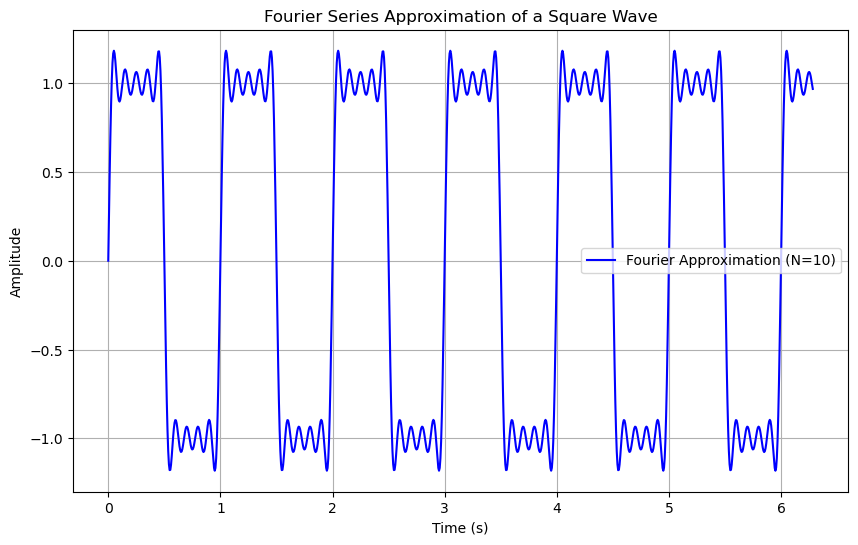

In [2]:
# Fourier Series for Square Wave
def fourier_series_square_wave(t, N):
    """
    Approximate a square wave using a Fourier series with N terms.
    """
    f_approx = 0
    for n in range(1, N + 1, 2):  # Odd harmonics only
        f_approx += (4 / (np.pi * n)) * np.sin(n * omega * t)
    return f_approx

# Generate the Fourier series approximation for a square wave with 10 terms
N_terms = 10
square_wave_approx = fourier_series_square_wave(t, N_terms)

# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(t, square_wave_approx, label=f'Fourier Approximation (N={N_terms})', color='blue')
plt.title('Fourier Series Approximation of a Square Wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

### 2. Fourier Transform
The Fourier transform extends the concept of the Fourier series to non-periodic signals. It converts a time-domain signal into a continuous frequency-domain representation.

Mathematical Representation:
For a continuous-time signal x(t), the Fourier transform X(f) is given by:
X(f) = ∫₋∞⁺∞ x(t) e^(-j 2π f t) dt
Where:
    • f is the frequency variable (in Hz),
    • X(f) is the frequency-domain representation of the signal.

The inverse Fourier transform is used to recover the time-domain signal from its frequency-domain representation:
x(t) = ∫₋∞⁺∞ X(f) e^(j 2π f t) df

Key Points:
    • The Fourier transform is useful for analyzing signals that are not periodic.
    • It decomposes a signal into its frequency components, providing insight into its spectral content.

Applications:
    • Signal processing
    • Communications (e.g., modulation, filtering)
    • Spectral analysis of signals


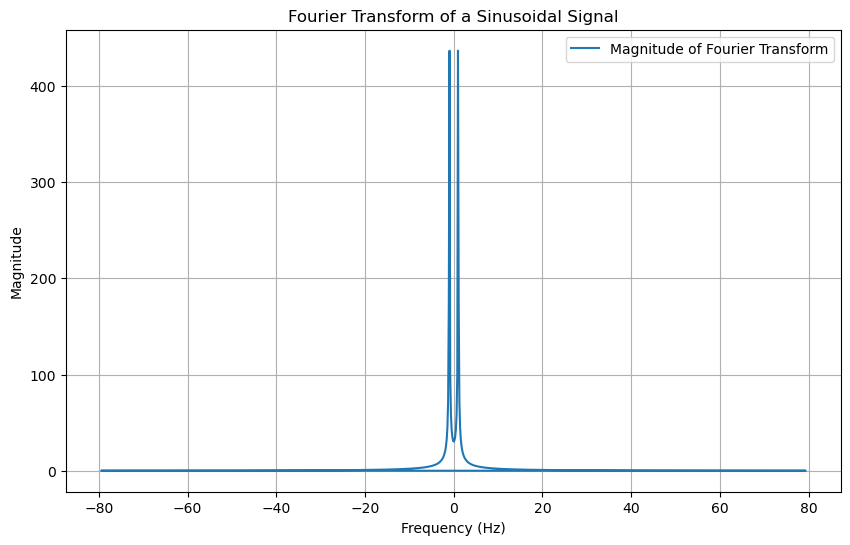

In [3]:
# Fourier Transform using scipy FFT (Fast Fourier Transform)
X_f = fft(A * np.sin(omega * t))  # Apply FFT to the signal

# Frequency axis for plotting the FFT result
f_axis = np.fft.fftfreq(len(t), t[1] - t[0])

# Plot the magnitude of the FFT result
plt.figure(figsize=(10, 6))
plt.plot(f_axis, np.abs(X_f), label='Magnitude of Fourier Transform')
plt.title('Fourier Transform of a Sinusoidal Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.show()

### 3. Laplace Transform
The Laplace transform is a powerful tool for analyzing dynamic systems, especially in the context of control systems and electrical engineering. It transforms a time-domain signal x(t) into a complex frequency domain representation.

Mathematical Representation:
The Laplace transform X(s) of a time-domain signal x(t) is given by:
X(s) = ∫₀⁺∞ x(t) e^(-st) dt
Where:
    • s = σ + jω is a complex frequency variable (with real part σ and imaginary part ω),
    • X(s) is the Laplace domain representation of x(t).

Key Points:
    • The Laplace transform is widely used for analyzing linear time-invariant (LTI) systems.
    • It handles both transient and steady-state behavior of systems.
    • The inverse Laplace transform recovers the original time-domain signal.

Applications:
    • Control systems
    • Circuit analysis
    • Differential equations


In [4]:
import sympy as sp

# Define symbols
t, s = sp.symbols('t s')

# Define the function f(t)
f_t = sp.exp(-t)

# Compute the Laplace Transform
laplace_transform = sp.laplace_transform(f_t, t, s)

# Display the result
laplace_transform

(1/(s + 1), -1, True)

### 4. Z-Transform
The Z-transform is similar to the Fourier transform but works with discrete-time signals. It provides a way to analyze discrete-time systems and is used primarily in digital signal processing (DSP) and control systems.

Mathematical Representation:
The Z-transform of a discrete-time signal x[n] is given by:
X(z) = ∑ₙ x[n] z^(-n)
Where:
    • z is a complex variable (z = re^(jω)),
    • X(z) is the Z-domain representation of the signal x[n].

The inverse Z-transform is used to recover the original signal x[n] from X(z):
x[n] = 1/2πj ∮ X(z) z^(n-1) dz

Key Points:
    • The Z-transform is useful for analyzing discrete-time systems and signals.
    • It can be used to derive system stability and perform system analysis in the Z-domain.
    • The inverse Z-transform recovers the time-domain signal.

Applications:
    • Digital signal processing (e.g., filter design)
    • Discrete-time system analysis
    • Control systems

In [5]:
# Z-Transform of a simple discrete-time signal: x[n] = a^n (where a is a constant)
from sympy import symbols, Sum
n, a, z = symbols('n a z')
x_n = a**n
z_transform = Sum(x_n * z**(-n), (n, 0, np.inf)).doit()

z_transform

Piecewise((1/(-a/z + 1), Abs(a/z) < 1), (Sum(a**n/z**n, (n, 0, oo)), True))

### 5. Frequency Domain Analysis of Systems
After transforming signals using the Fourier Transform, Laplace Transform, or Z-Transform, we can analyze systems in the frequency domain. This allows us to examine the response of systems to different frequencies.

In the case of linear time-invariant (LTI) systems, the system's behavior in the frequency domain can be characterized by its transfer function, H(s) for continuous systems (Laplace domain) or H(z) for discrete systems (Z-domain).

#### Example: Frequency Response of a Low-Pass Filter
A low-pass filter allows low-frequency signals to pass through while attenuating high-frequency signals. Its frequency response is typically defined as:
H(f) = 1 / (1 + j(2πfRC))
Where R is the resistance, C is the capacitance, and f is the frequency.

Key Points:
    • The frequency response describes how a system reacts to different input frequencies.
    • The transfer function provides insight into the system's behavior in both the time and frequency domains.


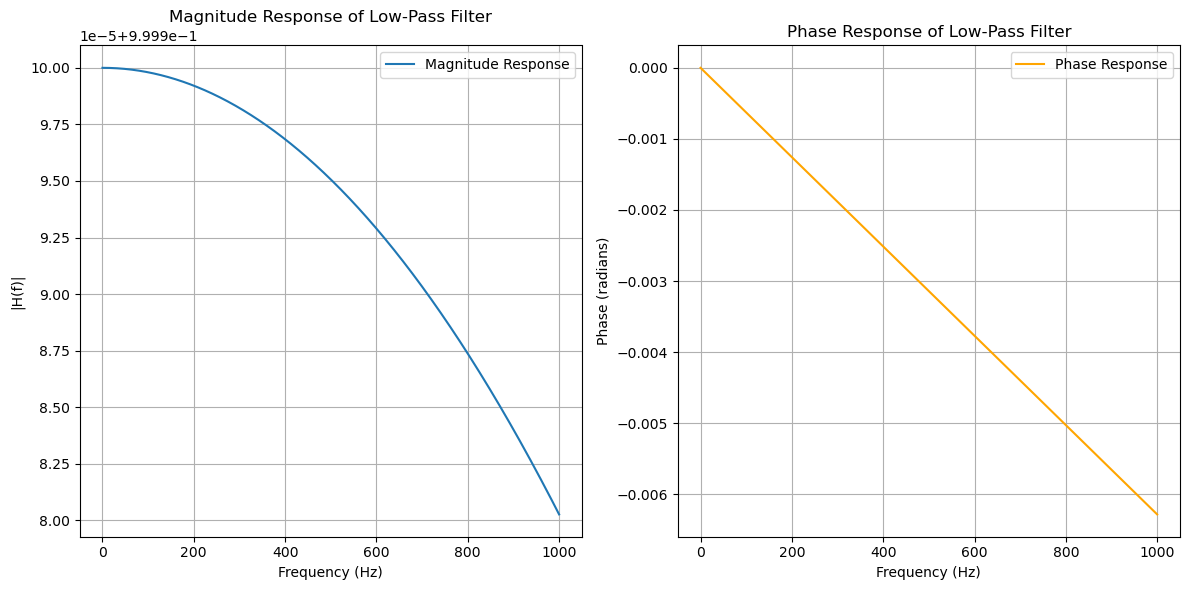

In [6]:
# Frequency Response of a Low-Pass Filter
R = 1  # Resistance in ohms
C = 1e-6  # Capacitance in farads
f = np.linspace(0, 1000, 1000)  # Frequency range from 0 to 1000 Hz
H_f = 1 / (1 + 1j * 2 * np.pi * f * R * C)  # Frequency response of low-pass filter

# Plot the magnitude and phase of the frequency response
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(f, np.abs(H_f), label='Magnitude Response')
plt.title('Magnitude Response of Low-Pass Filter')
plt.xlabel('Frequency (Hz)')
plt.ylabel('|H(f)|')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(f, np.angle(H_f), label='Phase Response', color='orange')
plt.title('Phase Response of Low-Pass Filter')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (radians)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Practice and Milestone 1

At this stage of the course, you’ll need to:

•	Learn Fourier Series & Transforms: Understand the mathematical foundations and applications of Fourier series and transforms. Practice by solving problems involving periodic and non-periodic signals.

•	Introduction to Laplace & Z-Transforms: Familiarize yourself with the basics of the Laplace and Z-transforms, particularly in the context of analyzing LTI systems.

•	Analyze Basic Systems in the Frequency Domain: Explore how different systems behave in the frequency domain, and understand the importance of frequency responses.

•	Practice with Sinusoidal & Exponential Inputs: Experiment with different types of inputs (sinusoidal, exponential) and analyze how systems respond to these signals in both time and frequency domains.


## Conclusion

In this lecture, we’ve laid the foundation for understanding some of the most essential tools for analyzing signals and systems in the frequency domain.

Fourier series, Fourier transforms, Laplace transforms, and Z-transforms each play crucial roles in signal processing, control systems, and various engineering disciplines.

Mastering these concepts will provide you with the tools to solve a wide range of practical problems in both continuous and discrete time.
